In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL

from pathlib import Path
import warnings

warnings.simplefilter('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 7)

In [107]:
path = Path('/home/jeremy/Documents')

transaction = pd.read_excel(path / 'Transactions.xlsx')
transaction['Transaction_Date'] = transaction['Transaction Date']
cols = ['Amount', 'Transaction_Date']
transaction_df = transaction[cols]
# transaction = transaction.drop(columns='Transaction Date')
transaction.head()

,Trace ID,Posting Date,Account No,Description,Amount,Posting S,Posted,Account Name,Unit ID,Transaction Type,...,Entry No,Transaction Type Charges,Card Acceptor Terminal ID,ATM Card No,Customer Names,Process Code,Reference No,Is Coop Bank,POS Vendor,Transaction_Date
0,USSD-98209269-152052,2025-01-24,0101-005423900,USSD Withdrawal,3022.4,NaN,0,HABOYA TEI MKO,M-PESA,Withdrawal,...,3616322,Balance Enquiry,NaN,254795321709,NaN,NaN,NaN,0,ATM Lobby,2025-01-24
1,USSD-662078485-60422,2025-01-22,0109-007815700,USSD Withdrawal,2922.4,NaN,0,ERICK MUNGA,M-PESA,Withdrawal,...,3613622,Balance Enquiry,NaN,254702307923,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
2,USSD-716572205-64135,2025-01-22,0101-017171700,USSD Withdrawal,4022.4,NaN,0,OMAR MAKORANI WACHU,M-PESA,Withdrawal,...,3613352,Balance Enquiry,NaN,254729501490,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
3,USSD-715659342-85289,2025-01-22,0101-014659300,USSD Withdrawal,4022.4,NaN,0,STANLEY BARSIBOI CHEPKIRWOK,M-PESA,Withdrawal,...,3613210,Balance Enquiry,NaN,254722660045,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
4,USSD-709957019-43649,2025-01-21,0101-021174300,USSD Withdrawal,2022.4,NaN,0,TIMAMU MWARAVINO CHEMBE,M-PESA,Withdrawal,...,3612562,Balance Enquiry,NaN,254112168233,NaN,NaN,NaN,0,ATM Lobby,2025-01-21


In [87]:
# transaction_df['Amount_Int'] = transaction_df['Amount'].astype(int)

In [108]:
transaction_df.head()

,Amount,Transaction_Date
0,3022.4,2025-01-24
1,2922.4,2025-01-22
2,4022.4,2025-01-22
3,4022.4,2025-01-22
4,2022.4,2025-01-21


In [109]:
# transaction_df.columns = transaction_df.columns.str.strip()
transaction_df['Transaction_Date'] = pd.to_datetime(transaction_df['Transaction_Date'])
transaction_df = transaction_df.set_index('Transaction_Date')
# transaction_df['Amount'] = pd.to_numeric(
#     transaction_df['Amount'].str.replace(',', ''), errors='coerce'
# )
transaction_df.head()

,Amount
Transaction_Date,
2025-01-24,3022.4
2025-01-22,2922.4
2025-01-22,4022.4
2025-01-22,4022.4
2025-01-21,2022.4


<Axes: xlabel='Transaction_Date'>

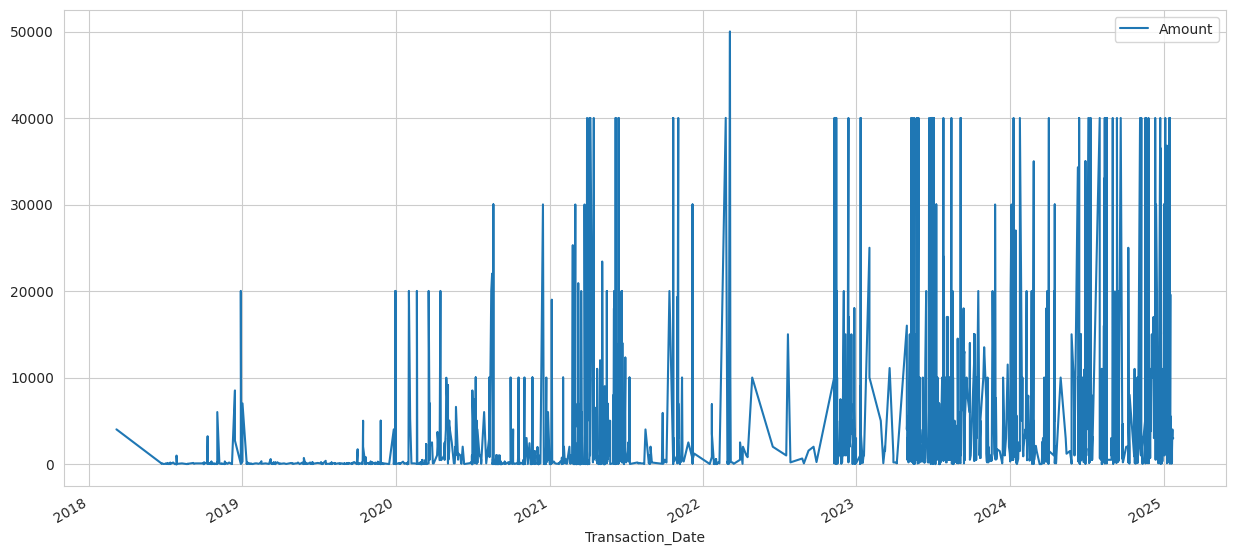

In [110]:
transaction_df.plot(figsize=(15,7))

In [111]:
transaction_df.isna().sum()

Amount    0
dtype: int64

In [112]:
# create plot_outliers function that will be used later in the recipes
def plot_outliers(outliers, df, method='KNN', halignment='right', valignment='bottom', labels=False):
    '''
    outliers: these are the known outliers dates like holidays
    df: dataframe to check and plot the outliers
    '''
    
    ax = df.plot(alpha=.6)

    if labels:
        for i in outliers['value'].items():
            plt.plot(i[0], i[1], 'rx')
            plt.text(i[0], i[1], f'{i[0].date()}', horizontalalignment=halignment, verticalalignment=valignment)
    else:
        df.loc[outliers.index].plot(ax=ax, style='rx')

    plt.title(f'Transactions - {method}')
    plt.xlabel('date'); plt.ylabel('Number of Transactions')
    plt.legend(['transactions', 'outliers'])
    plt.show()

In [113]:
transaction_df = transaction_df.resample('21D').mean()

transaction_df.head()

,Amount
Transaction_Date,
2018-03-07,4032.0
2018-03-28,NaN
2018-04-18,NaN
2018-05-09,NaN
2018-05-30,NaN


In [114]:
transaction_df.isna().sum()

Amount    7
dtype: int64

In [97]:
transaction_dates = ['2018-12-24', '2018-12-25', '2018-12-26', '2018-12-31', '2019-01-01', 
                     '2019-12-24', '2019-12-25', '2019-12-26', '2019-12-31', '2020-01-01', 
                     '2020-12-24', '2020-12-25', '2020-12-26', '2020-12-31', '2021-01-01',
                     '2021-12-24', '2021-12-25', '2021-12-26', '2021-12-31', '2022-01-01',
                     '2022-12-24', '2022-12-25', '2022-12-26', '2022-12-31', '2023-01-01',
                     '2023-12-24', '2023-12-25', '2023-12-26', '2023-12-31', '2024-01-01',
                     '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-31', '2025-01-01']

In [64]:
known_outliers = transaction_df.loc[transaction_dates]
plot_outliers(known_outliers, transaction_df, 'KNN')

KeyError: "['2018-12-24', '2018-12-25', '2018-12-31', '2019-01-01', '2019-12-24', '2019-12-25', '2019-12-26', '2019-12-31', '2020-01-01', '2020-12-24', '2020-12-25', '2020-12-26', '2020-12-31', '2021-01-01', '2021-12-24', '2021-12-25', '2021-12-26', '2021-12-31', '2022-01-01', '2022-12-24', '2022-12-25', '2022-12-26', '2022-12-31', '2023-01-01', '2023-12-24', '2023-12-25', '2023-12-26', '2023-12-31', '2024-01-01', '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-31', '2025-01-01'] not in index"

<Axes: ylabel='Count'>

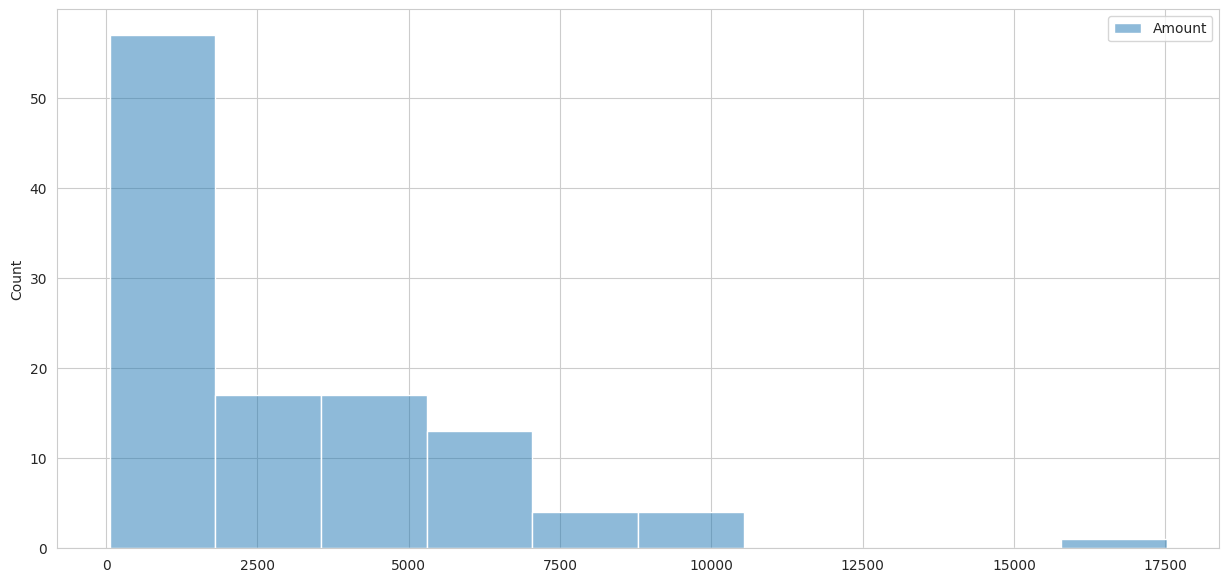

In [115]:
sns.histplot(transaction_df)

<Axes: xlabel='Transaction_Date'>

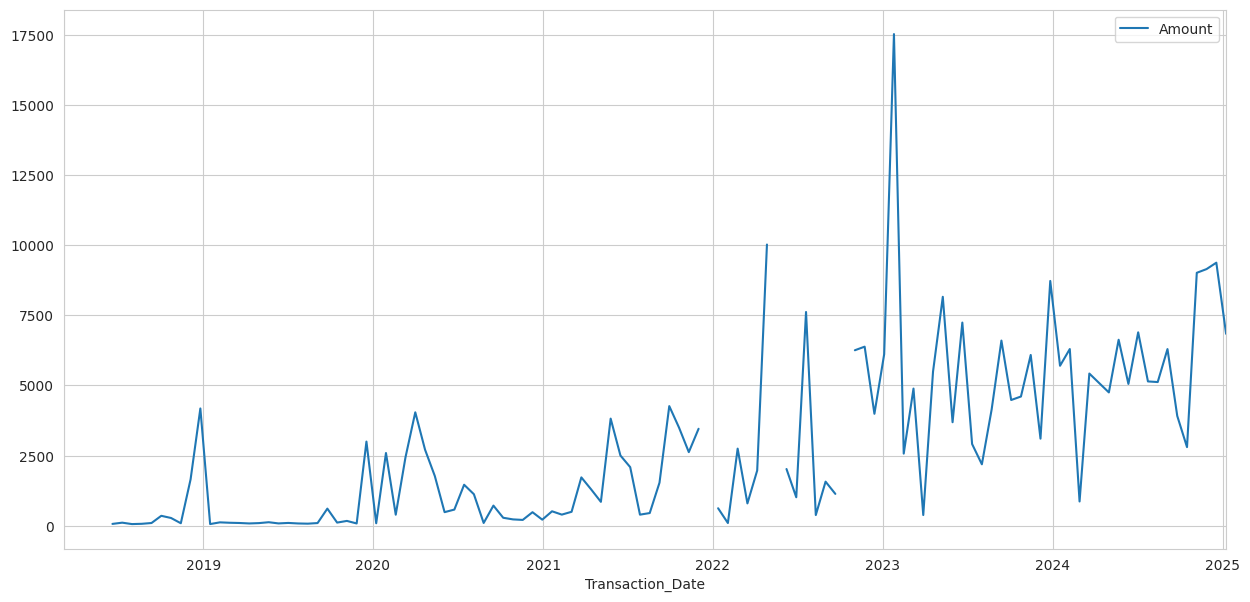

In [116]:
transaction_df.plot()

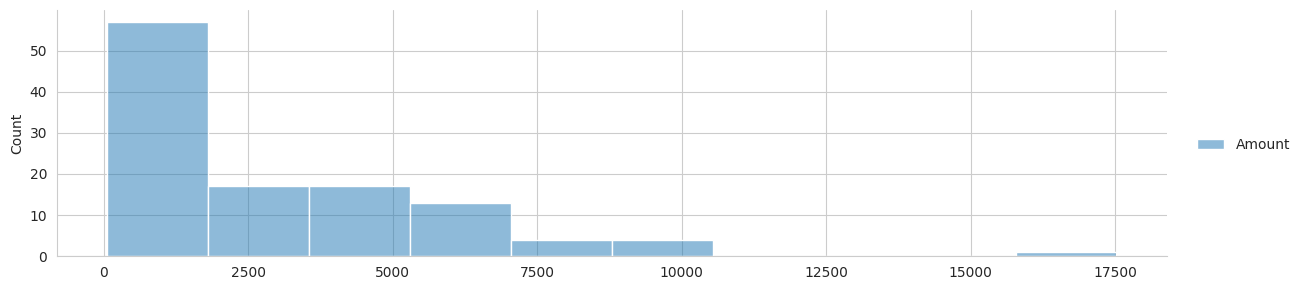

In [117]:
sns.displot(transaction_df, height=3, kind='hist', aspect=4)

<Axes: ylabel='Amount'>

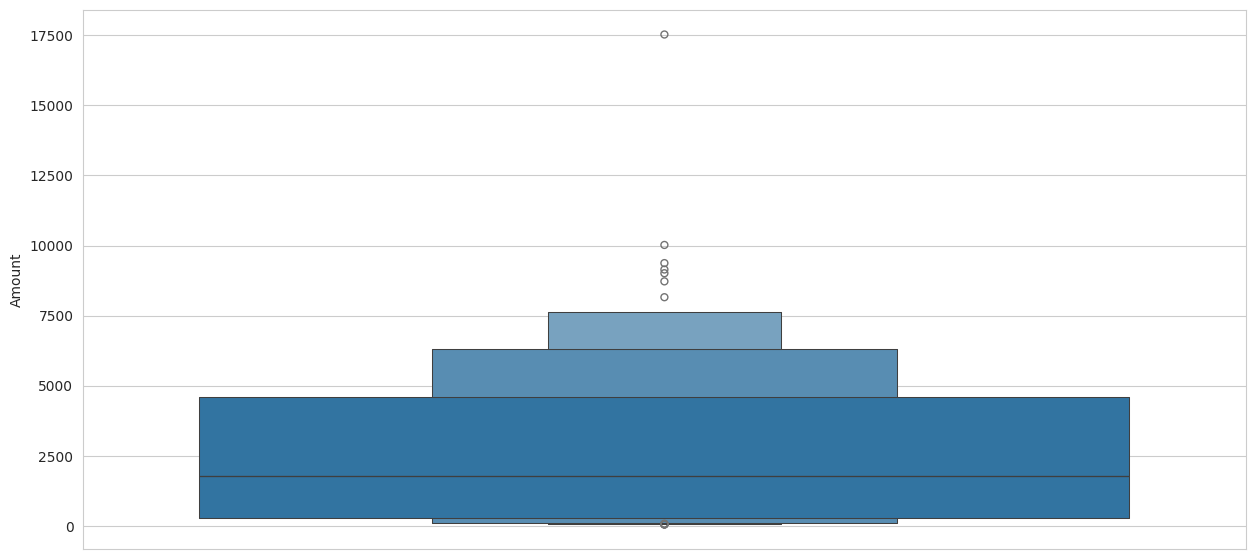

In [118]:
sns.boxenplot(transaction_df['Amount'])

You can filter the outliers in the box plot above by extracting amount greater than 7500.

<Axes: ylabel='Amount'>

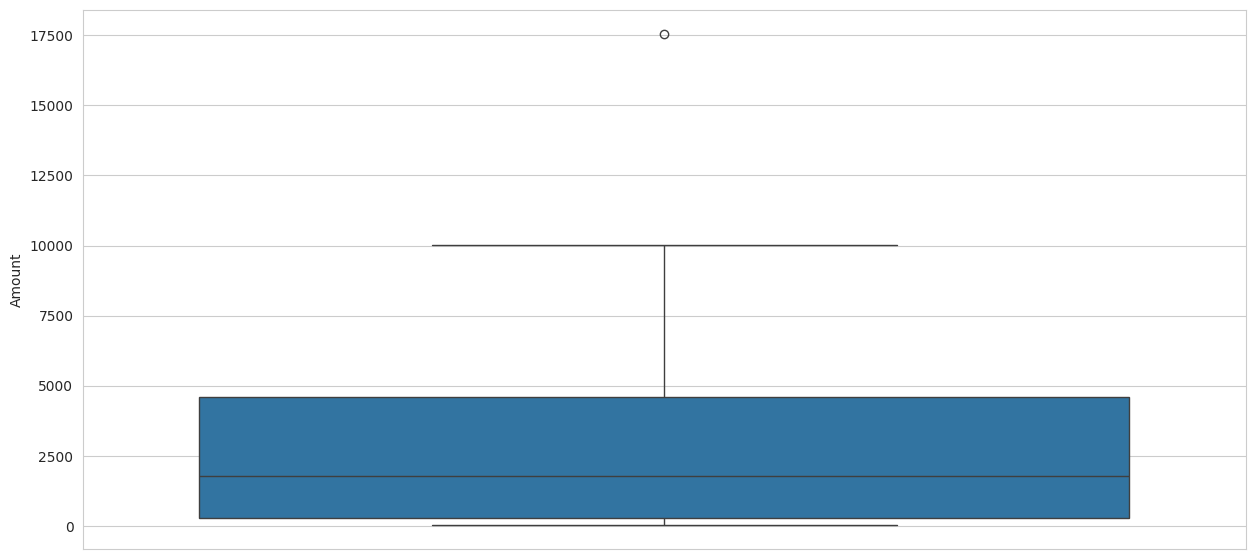

In [119]:
sns.boxplot(transaction_df['Amount'])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

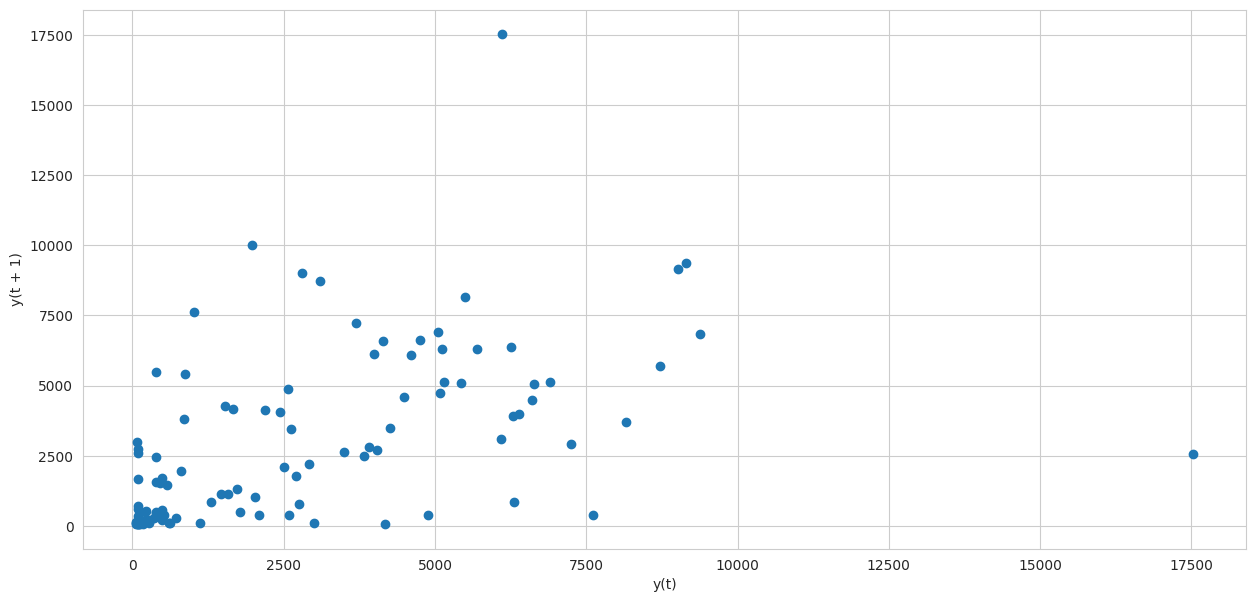

In [120]:
from pandas.plotting import lag_plot

lag_plot(transaction_df)

It shows there is an autocorrelation between the values i.e future (predicted) values and previous values are correlated with each other.

In [121]:
#  Determine the outliers using Turkey fences
percentiles = [0, .05, .1, .25, .5, .75, .90, .95, 1]

transaction_df.describe(percentiles=percentiles)

,Amount
count,113.000000
mean,2795.354370
std,3026.593968
min,60.000000
0%,60.000000
5%,82.100000
10%,95.294118
25%,285.288889
50%,1773.125000
75%,4606.170909


In [122]:
def iqr_outliers(df, column_name):
    data = df[column_name]

    q1, q3 = np.percentile(df, [25, 75])
    iqr = q3 - q1
    
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    return df[(data < lower_fence) | (data > upper_fence)]

In [123]:
outliers = iqr_outliers(transaction_df, 'Amount')
outliers

,Amount
Transaction_Date,


In [124]:
import scipy.stats as stats

stats.norm.ppf(0.75)         # normalization factor used in the formula

0.6744897501960817

In [127]:
def modified_z_score(df, degree=3):
    data = df.copy()
    s = stats.norm.ppf(0.75)
    numerator = s * (data - data.median())
    MAD = np.abs(data - data.median()).median()
    data['modified_zscore'] = numerator / MAD
    outliers = data[(data['modified_zscore'] > degree) | (data['modified_zscore'] < -degree)]

    return outliers['Amount'], data

array([[<Axes: title={'center': 'Amount'}>,
        <Axes: title={'center': 'modified_zscore'}>]], dtype=object)

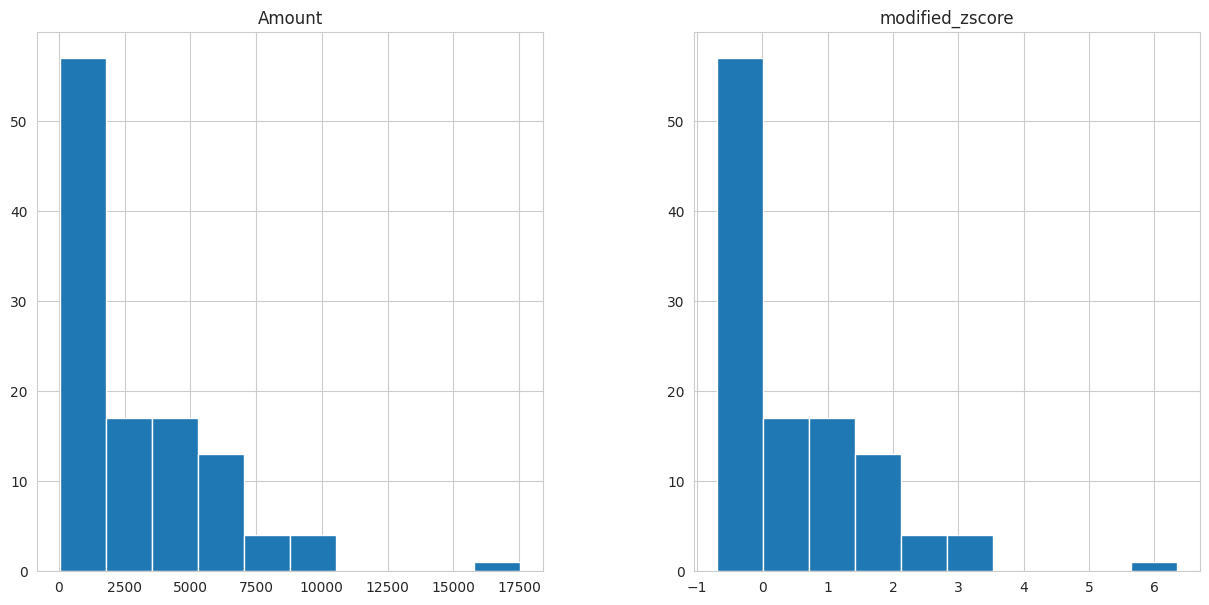

In [128]:
threshold = 3
outliers, transformed_data = modified_z_score(transaction_df, threshold)

transformed_data.hist()